In [1]:
# 1. Create a hidden folder named .kaggle in your root directory
!mkdir -p ~/.kaggle

# 2. Copy the uploaded kaggle.json file into that folder
!cp kaggle.json ~/.kaggle/

# 3. Change permissions so the API key isn't publicly readable
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
# all imports
from zipfile import ZipFile
import json
import os
import matplotlib.pyplot as plt
from keras.src.backend import image_data_format
import keras
from keras.layers import Conv2D , Flatten , Dense , MaxPool2D , Rescaling
from  keras.models import Sequential
import tensorflow as tf
from tensorflow import keras
import numpy as np
from keras.preprocessing import image

In [3]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:16<00:00, 129MB/s]



In [4]:
with ZipFile('/content/plantvillage-dataset.zip' , 'r') as zip_ref:
  zip_ref.extractall()

In [5]:
print(os.listdir('plantvillage dataset'))

['color', 'segmented', 'grayscale']


In [8]:
print(len(os.listdir('/content/plantvillage dataset/color')))
print(os.listdir('/content/plantvillage dataset/color'))

38
['Cherry_(including_sour)___Powdery_mildew', 'Apple___Apple_scab', 'Potato___Late_blight', 'Tomato___Early_blight', 'Tomato___healthy', 'Strawberry___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Apple___healthy', 'Apple___Cedar_apple_rust', 'Peach___healthy', 'Tomato___Septoria_leaf_spot', 'Tomato___Bacterial_spot', 'Potato___healthy', 'Tomato___Target_Spot', 'Pepper,_bell___Bacterial_spot', 'Grape___Black_rot', 'Raspberry___healthy', 'Grape___Esca_(Black_Measles)', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Tomato___Leaf_Mold', 'Tomato___Late_blight', 'Apple___Black_rot', 'Strawberry___Leaf_scorch', 'Corn_(maize)___Common_rust_', 'Soybean___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Corn_(maize)___Northern_Leaf_Blight', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Grape___healthy', 'Tomato___Tomato_mosaic_virus', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy

In [7]:
print(len(os.listdir('/content/plantvillage dataset/grayscale')))
print(os.listdir('/content/plantvillage dataset/grayscale'))

38
['Grape___Esca_(Black_Measles)', 'Tomato___Tomato_mosaic_virus', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Raspberry___healthy', 'Strawberry___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Leaf_Mold', 'Cherry_(including_sour)___Powdery_mildew', 'Tomato___Bacterial_spot', 'Pepper,_bell___Bacterial_spot', 'Corn_(maize)___healthy', 'Tomato___Late_blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Peach___Bacterial_spot', 'Squash___Powdery_mildew', 'Soybean___healthy', 'Blueberry___healthy', 'Tomato___Target_Spot', 'Peach___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy', 'Tomato___Septoria_leaf_spot', 'Apple___Apple_scab', 'Corn_(maize)___Northern_Leaf_Blight', 'Apple___Black_rot', 'Strawberry___Leaf_scorch', 'Grape___Black_rot', 'Potato___Late_blight', 'Pepper,_bell___healthy', 'Corn_(maize)___Common_rust_', 'Apple___healthy', 'Tomato___Early_blight', 'Apple___Cedar_apple_rust', 'Potat

In [8]:
print(len(os.listdir('/content/plantvillage dataset/segmented')))
print(os.listdir('/content/plantvillage dataset/segmented'))

38
['Grape___Esca_(Black_Measles)', 'Tomato___Tomato_mosaic_virus', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Raspberry___healthy', 'Strawberry___healthy', 'Cherry_(including_sour)___healthy', 'Tomato___Leaf_Mold', 'Cherry_(including_sour)___Powdery_mildew', 'Tomato___Bacterial_spot', 'Pepper,_bell___Bacterial_spot', 'Corn_(maize)___healthy', 'Tomato___Late_blight', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Peach___Bacterial_spot', 'Squash___Powdery_mildew', 'Soybean___healthy', 'Blueberry___healthy', 'Tomato___Target_Spot', 'Peach___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___healthy', 'Tomato___Septoria_leaf_spot', 'Apple___Apple_scab', 'Corn_(maize)___Northern_Leaf_Blight', 'Apple___Black_rot', 'Strawberry___Leaf_scorch', 'Grape___Black_rot', 'Potato___Late_blight', 'Pepper,_bell___healthy', 'Corn_(maize)___Common_rust_', 'Apple___healthy', 'Tomato___Early_blight', 'Apple___Cedar_apple_rust', 'Potat

so there are 38 classes

In [9]:
print(len(os.listdir('/content/plantvillage dataset/color/Apple___healthy')))
print(os.listdir('/content/plantvillage dataset/color/Apple___healthy'))

1645
['5e39c42c-b499-495f-8612-eb3a1079d594___RS_HL 6047.JPG', 'bdf80993-e555-4609-8a83-7f1676bce18b___RS_HL 5682.JPG', 'd29e5681-1f95-4efa-9196-9ecd45538d87___RS_HL 7328.JPG', 'e2cce5a6-04a9-436d-8e56-3bf4979b47bc___RS_HL 5886.JPG', 'de1cec8e-3880-4410-9fdb-99e79ce2dcbe___RS_HL 7819.JPG', 'e6b195c1-8aa7-4853-9885-2a6db55b99aa___RS_HL 7409.JPG', '3643fe1d-9523-47cf-9952-7e2ecb027338___RS_HL 5704.JPG', '3100088b-5df1-43b2-a1d9-8ff1d414b67b___RS_HL 5834.JPG', '278e3aec-395c-457a-8fd0-ddf0ad8f3056___RS_HL 7377.JPG', '381f3abb-208f-4f52-b7a2-57e35f31c373___RS_HL 5680.JPG', 'd215e01d-93aa-41cc-9212-614c93151cca___RS_HL 8068.JPG', 'bc9b490b-eb06-4b0a-bfcc-f90478e0418b___RS_HL 7677.JPG', 'f2cda910-55c7-46d7-b1a2-9a3bb9792148___RS_HL 6274.JPG', '1ab74120-9cfd-47dd-9a80-ee37f2328be6___RS_HL 7667.JPG', 'd163d7d1-4557-443d-8584-dab6934f858f___RS_HL 7545.JPG', 'b6d4b26d-cc9d-4250-ae1f-5678b5fcd068___RS_HL 8071.JPG', '77273304-be77-4b74-a4ed-cd42826f4635___RS_HL 8178.JPG', 'f32ff514-bb33-437d-96bb-

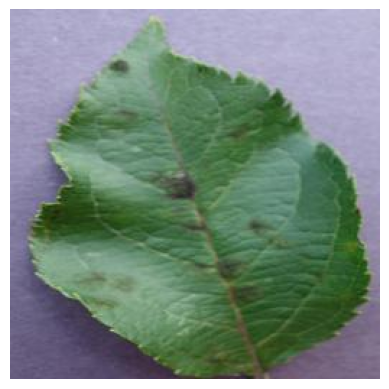

In [10]:
### example image
image_path = '/content/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'
img = plt.imread(image_path)

plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
image = plt.imread(image_path)

print(image)

[[[167 163 196]
  [166 162 195]
  [165 161 194]
  ...
  [185 182 211]
  [183 180 209]
  [181 178 207]]

 [[170 166 199]
  [169 165 198]
  [168 164 197]
  ...
  [186 183 212]
  [184 181 210]
  [183 180 209]]

 [[170 166 199]
  [169 165 198]
  [168 164 197]
  ...
  [188 185 214]
  [186 183 212]
  [185 182 211]]

 ...

 [[100  90 124]
  [102  92 126]
  [104  94 128]
  ...
  [126 110 137]
  [126 110 137]
  [126 110 137]]

 [[101  91 125]
  [102  92 126]
  [103  93 127]
  ...
  [122 106 133]
  [123 107 134]
  [123 107 134]]

 [[104  94 128]
  [103  93 127]
  [102  92 126]
  ...
  [121 105 132]
  [122 106 133]
  [123 107 134]]]


In [12]:
img_size = (256,256)
batch_size = 32

In [13]:
import tensorflow as tf

# Loading the three distinct training chunks (80% each)
train_color = tf.keras.utils.image_dataset_from_directory(
    '/content/plantvillage dataset/color',
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)
train_gray = tf.keras.utils.image_dataset_from_directory(
    '/content/plantvillage dataset/grayscale',
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)
train_seg = tf.keras.utils.image_dataset_from_directory(
    '/content/plantvillage dataset/segmented',
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_color = tf.keras.utils.image_dataset_from_directory(
    '/content/plantvillage dataset/color',
    validation_split=0.2, subset="validation", seed=42,
    image_size=img_size, batch_size=batch_size, label_mode="categorical"
)
val_gray = tf.keras.utils.image_dataset_from_directory(
    '/content/plantvillage dataset/grayscale',
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)
val_seg = tf.keras.utils.image_dataset_from_directory(
    '/content/plantvillage dataset/segmented',
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54306 files belonging to 38 classes.
Using 43445 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Found 54306 files belonging to 38 classes.
Using 10861 files for validation.


In [14]:
train_ds = tf.data.Dataset.sample_from_datasets([train_color , train_seg, train_gray])
validation_ds =  tf.data.Dataset.sample_from_datasets([val_color,val_gray,val_seg])

In [15]:
# optimization to keep GPU working at full capacity
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)

In [16]:
model = Sequential([
    Rescaling(1./255, input_shape=(256,256, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(2, 2),

    Conv2D(128,(3,3) , activation='relu'),
    MaxPool2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(38, activation='softmax')  # as we know there are 38 classes in the dataset
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,594,470 (112.89 MB)

 Trainable params: 29,594,470 (112.89 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam' , loss = 'categorical_crossentropy' , metrics= ['accuracy'])

In [55]:
history = model.fit(train_ds ,
                    epochs = 5 ,
                    validation_data=validation_ds
                    )

Epoch 1/5
   4074/Unknown 287s 69ms/step - accuracy: 0.6756 - loss: 1.1869

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4074/4074 ━━━━━━━━━━━━━━━━━━━━ 310s 75ms/step - accuracy: 0.8157 - loss: 0.6332 - val_accuracy: 0.8713 - val_loss: 0.4295
Epoch 2/5
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 299s 73ms/step - accuracy: 0.9633 - loss: 0.1150 - val_accuracy: 0.8662 - val_loss: 0.5590
Epoch 3/5
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 300s 74ms/step - accuracy: 0.9789 - loss: 0.0653 - val_accuracy: 0.8848 - val_loss: 0.5344
Epoch 4/5
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 293s 72ms/step - accuracy: 0.9854 - loss: 0.0473 - val_accuracy: 0.8666 - val_loss: 0.7951
Epoch 5/5
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 291s 72ms/step - accuracy: 0.9873 - loss: 0.0416 - val_accuracy: 0.8735 - val_loss: 0.7284


In [60]:
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_ds)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
1020/1020 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.8735 - loss: 0.7284
Validation Accuracy: 87.35%


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
model.save('plant_disease_prediction_model.keras')

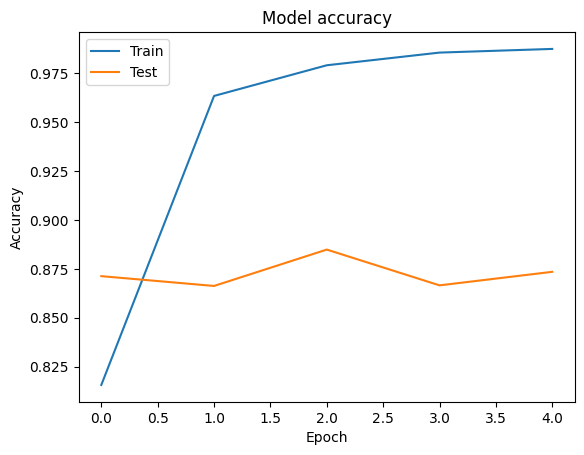

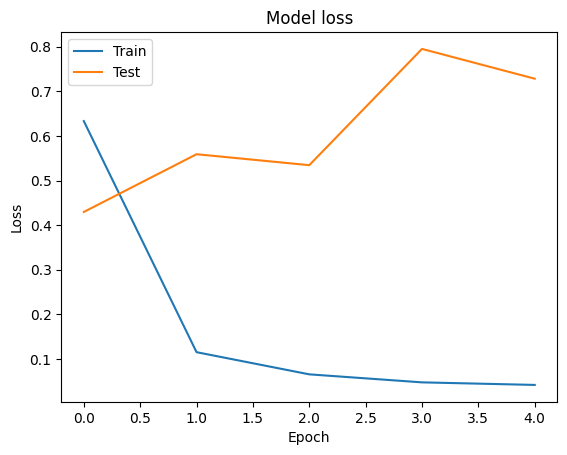

In [61]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [112]:
def load_and_preprocess_image(image_path , target_size = (256,256)):
  img = image.load_img(image_path , target_size=target_size)
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array , axis = 0)
  return img_array

def predict_image_class(model , image_path , class_indices):
  preprocessed_img = load_and_preprocess_image(image_path)
  predictions = model.predict(preprocessed_img)
  predicted_class_index = np.argmax(predictions , axis = 1)[0]
  predicted_class_name =  class_indices[predicted_class_index]
  return predicted_class_name


In [19]:
class_names = train_color.class_names

class_indices = {i: name for i, name in enumerate(class_names)}

class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [20]:
json.dump(class_indices, open('class_indices.json', 'w'))

In [115]:
image_path = '/content/plantvillage dataset/color/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/01a02916-5d4c-4256-936b-6b1a9ee65b11___RS_GLSp 9276.JPG'
predict = predict_image_class(model , image_path=image_path , class_indices=class_indices)
print(predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
